In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy
from matplotlib.animation import FuncAnimation

# First Attempt

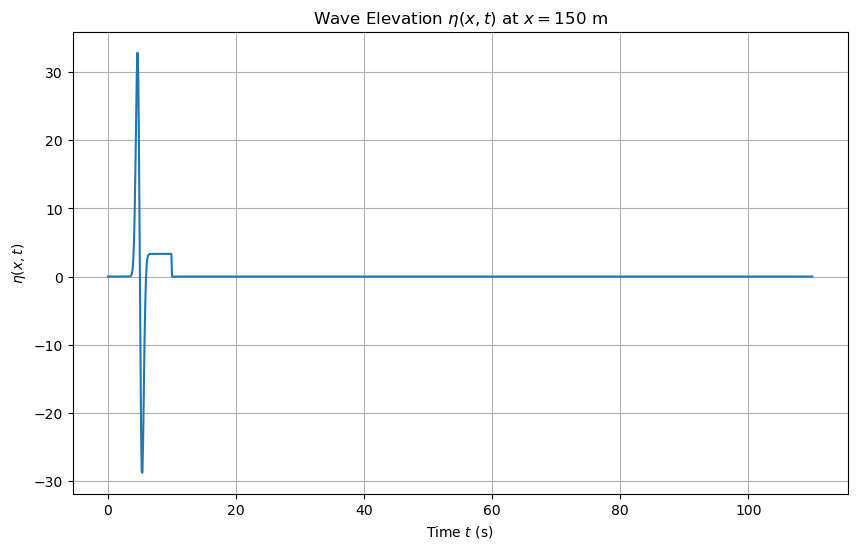

In [3]:
def plot_eta(x_target):

    h0 = 100
    alpha = 0.1
    g = 9.8
    LV = 100 # Box length = 50m; Velocity = 2m/s
    t_immersed = 5 # Box thickness = 20m ; time = 20/2 = 10
    rho = 1000
    PL = 5e6 # Pressure is 1e5 Pa
    epsilon = 0.5 # Width of pulse

    h_x = h0 - alpha * x_target

    tau_x = (2 / (alpha * np.sqrt(g))) * (np.sqrt(h0) - np.sqrt(h_x))

    t_end = tau_x + t_immersed + 100 # So as not to trim the graph
    t = np.linspace(0, t_end, 1000)

    t_prime = t - tau_x # Time lag to give to piecewise function

    # Piecewise u function
    u = np.where((t_prime >= 0) & (t_prime <= t_immersed), LV / h0, 0.0)

    amp1 = (h0 / h_x)**0.25 * (h0 / g)**0.5
    eta_1 = amp1 * u

    amp2 = (h0 / h_x)**0.25 * (PL) / (rho * g * np.sqrt(g * h0))
    d_delta = (-2 * t_prime / (epsilon**3 * np.sqrt(np.pi))) * np.exp(-(t_prime / epsilon)**2)

    eta_2 = amp2 * d_delta

    eta_total = eta_1 + eta_2

    plt.figure(figsize=(10, 6))
    # plt.plot(t, eta_1, label=f'x_target = {x_target} m')
    # plt.plot(t, eta_2, label=f'x_target = {x_target} m')
    plt.plot(t, eta_total, label=f'x_target = {x_target} m')
    plt.title(f'Wave Elevation $\\eta(x,t)$ at $x = {x_target}$ m')
    plt.xlabel('Time $t$ (s)')
    plt.ylabel('$\\eta(x,t)$')
    plt.grid(True)
    plt.show()

plot_eta(150)

# Second Attempt

We give the function a x coordinate, and it generates surface elevation as a function of time for that location

In [ ]:
# Parameters and constants
g = 9.81 # Gravitational acceleration (m/s^2)
rho = 1000 # Density of water (kg/m^3)

# Lake configuration parameters
h0 = 100 # Initial water depth (m)
x_s = 500 # Coordinate where the flat bed ends (m)
theta = 10 # Slope angle in degrees
alpha = np.tan(np.radians(theta)) # Slope of the bed

# Landslide block parameters
L = 25.0 # Length of block
d = 12.0 # Depth of block
P = 5e5 # Initial impact pressure in pascals

def plot_wave_profile(x_obs):
    
    # Local depth h(x) at observation point
    if x_obs <= x_s:
        h_x = h0
    else:
        h_x = max(1e-3, h0 - alpha * (x_obs - x_s))

    shoaling_amp_vertical = (h0 / h_x) ** 0.25
    shoaling_comp_horizontal = (h0 / h_x) ** 0.5

    c0 = np.sqrt(g * h0)

    t_arrival = x_obs / c0
    t_start = max(0.1, t_arrival - 20.0) 
    t_end = t_arrival + 100.0
    t = np.linspace(t_start, t_end, 1500)

    chi = (0.5 * c0 * (h0**2) * t) ** (1/3)

    z_shoal = shoaling_comp_horizontal * ((x_obs - c0 * t) / chi)

    # Components of Airy function
    ai, aip, _, _ = airy(z_shoal)

    # Impulse phase component
    eta_I = - (P * L / (2 * rho)) * np.sqrt(h0/g) * (1 / (chi**2)) * aip

    # Wave generator phase component
    eta_V = (L * d / chi) * ai

    eta_total = shoaling_amp_vertical * (eta_I + eta_V)

    plt.figure(figsize=(10,6))

    plt.plot(t, eta_total, label=r'Total Wave Profile ($\eta$)', linewidth = 2, color="black")
    plt.plot(t, shoaling_amp_vertical * eta_I, label='Impulse Component', linestyle='--', alpha=0.7)
    plt.plot(t, shoaling_amp_vertical * eta_V, label='Wave Gen Component', linestyle=':', alpha=0.7)

    plt.title(f'Wave Profile at a fixed position $x = {x_obs}$ m\n')
    plt.xlabel('Time (s)')
    plt.ylabel(r'Surface Elevation $\eta$ (m)')

    plt.grid(True)
    plt.legend()
    plt.show()

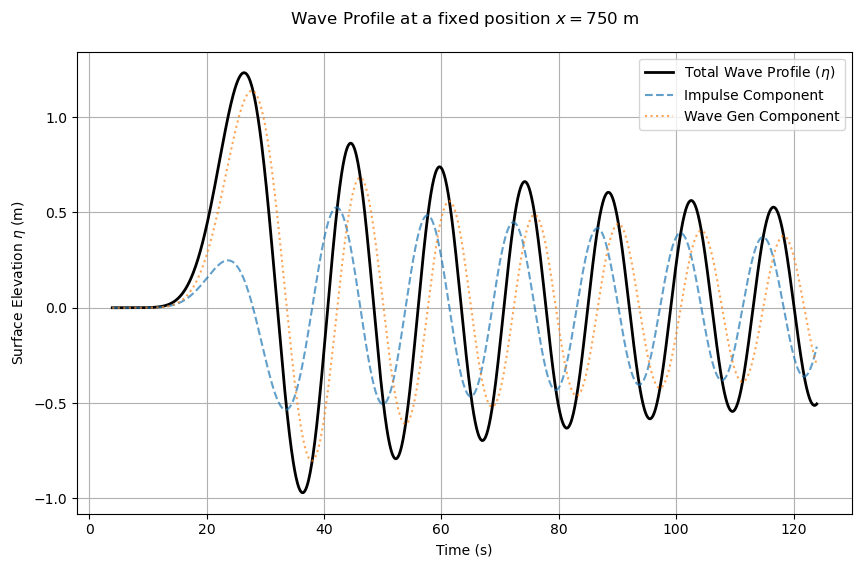

In [23]:
plot_wave_profile(750)

We give the function a time, and it generates the surface elevation for the whole lake!

In [15]:
# Parameters and constants
g = 9.81 # Gravitational acceleration (m/s^2)
rho = 1000 # Density of water (kg/m^3)

# Lake configuration parameters
h0 = 100 # Initial water depth (m)
x_s = 500 # Coordinate where the flat bed ends (m)
theta = 10 # Slope angle in degrees
alpha = np.tan(np.radians(theta)) # Slope of the bed

# Landslide block parameters
L = 25.0 # Length of block
d = 12.0 # Depth of block
P = 5e5 # Initial impact pressure in pascals

def plot_spatial_profile(t_obs):

    # To prevent division by zero in chi
    t_obs = max(0.1, t_obs)

    # Determine the exact shoreline coordinate
    x_shoreline = x_s + (h0 / alpha)
    x = np.linspace(0, x_shoreline, 2000)

    # Vectorize the depth calculation h(x)
    h_x = np.where(x <= x_s, h0, h0 - alpha * (x - x_s))
    h_x = np.maximum(1e-3, h_x) # Prevent exact zero for shoaling calculations

    shoaling_amp_vertical = (h0 / h_x) ** 0.25
    shoaling_comp_horizontal = (h0 / h_x) ** 0.5

    c0 = np.sqrt(g * h0)

    chi = (0.5 * c0 * (h0**2) * t_obs) ** (1/3)

    z_shoal = shoaling_comp_horizontal * ((x - c0 * t_obs) / chi)

    # Components of Airy function
    ai, aip, _, _ = airy(z_shoal)

    # Impulse phase component
    eta_I = - (P * L / (2 * rho)) * np.sqrt(h0/g) * (1 / (chi**2)) * aip

    # Wave generator phase component
    eta_V = (L * d / chi) * ai

    eta_total = shoaling_amp_vertical * (eta_I + eta_V)

    # Plotting
    plt.figure(figsize=(10,6))

    plt.plot(x, eta_total, label=r'Total Wave Profile ($\eta$)', linewidth=2, color="black")
    plt.plot(x, shoaling_amp_vertical * eta_I, label='Impulse Component', linestyle='--', alpha=0.7)
    plt.plot(x, shoaling_amp_vertical * eta_V, label='Wave Gen Component', linestyle=':', alpha=0.7)

    # Add a marker for the start of the slope
    plt.axvline(x=x_s, color='black', linestyle=':', alpha=0.5, label='Ramp')

    plt.title(f'Spatial Wave Profile at Time $t = {t_obs}$ s\n')
    plt.xlabel('Distance $x$ (m)')
    plt.ylabel(r'Surface Elevation $\eta$ (m)')
    
    # Restrict x-axis strictly to the physical domain
    plt.xlim(0, x_shoreline)
    
    plt.grid(True)
    plt.legend()
    plt.show()

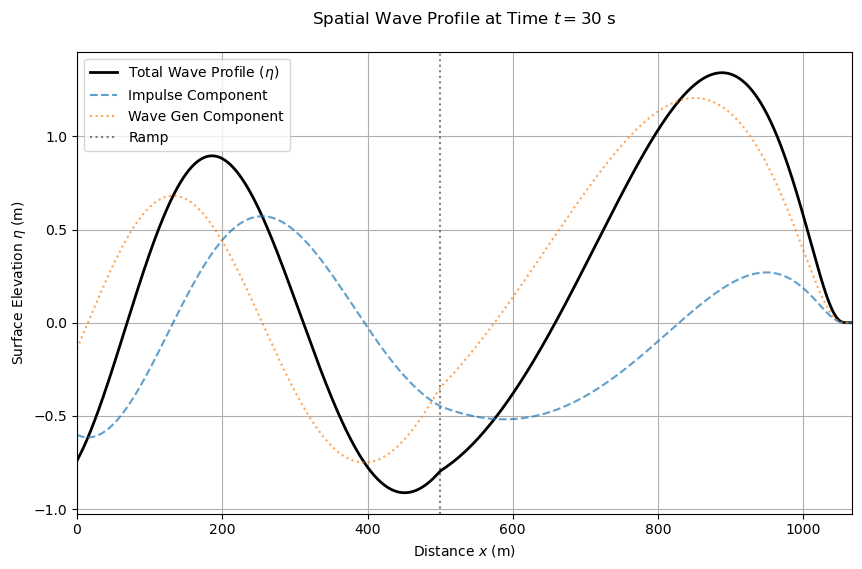

In [17]:
plot_spatial_profile(30)

Some fancy effects are observed at point where depth tends to zero; Need to figure out a way to handle it! Otherwise this does have shoaling and everything!

In [ ]:
# Parameters and constants
g = 9.81 # Gravitational acceleration (m/s^2)
rho = 1000 # Density of water (kg/m^3)

# Lake configuration parameters
h0 = 100 # Initial water depth (m)
x_s = 500 # Coordinate where the flat bed ends (m)
theta = 10 # Slope angle in degrees
alpha = np.tan(np.radians(theta)) # Slope of the bed

# Landslide block parameters
L = 25.0 # Length of block
d = 12.0 # Depth of block
P = 5e5 # Initial impact pressure in pascals

def create_wave_gif(t_max, filename="wave_propagation.gif", frames=150, fps=15):

    x_shoreline = x_s + (h0 / alpha)
    x = np.linspace(0, x_shoreline, 1500)
    
    h_x = np.where(x <= x_s, h0, h0 - alpha * (x - x_s))
    h_x = np.maximum(1e-3, h_x) 
    
    shoaling_amp_vertical = (h0 / h_x) ** 0.25
    shoaling_comp_horizontal = (h0 / h_x) ** 0.5
    c0 = np.sqrt(g * h0)

    # Start slightly above 0 to prevent division by zero in chi
    t_array = np.linspace(0.1, t_max, frames)

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Initialize empty line objects
    line_total, = ax.plot([], [], label=r'Total Wave ($\eta$)', color="black", linewidth=2)
    line_I, = ax.plot([], [], label='Impulse Component', linestyle='--', alpha=0.6)
    line_V, = ax.plot([], [], label='Wave Gen Component', linestyle=':', alpha=0.6)
    
    # Static plot elements
    ax.axvline(x=x_s, color='gray', linestyle=':', alpha=0.5, label='Start of Slope')
    ax.set_xlim(0, x_shoreline)
    
    # You may need to tune these values based on your specific pressure (P) inputs.
    ax.set_ylim(-2, 2) 
    
    ax.set_xlabel('Distance $x$ (m)')
    ax.set_ylabel(r'Surface Elevation $\eta$ (m)')
    ax.set_title('Tsunami Wave Propagation over Sloping Bed')
    ax.grid(True)
    ax.legend(loc='upper left')

    # Text box to display current time in the animation
    time_text = ax.text(0.85, 0.95, '', transform=ax.transAxes, 
                        fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    def init():
        """Initializes the background of the animation."""
        line_total.set_data([], [])
        line_I.set_data([], [])
        line_V.set_data([], [])
        time_text.set_text('')
        return line_total, line_I, line_V, time_text

    def update(frame_idx):

        """
        Updates the plot lines for each frame.
        """

        t_obs = t_array[frame_idx]
        
        chi = (0.5 * c0 * (h0**2) * t_obs) ** (1/3)
        z_shoal = shoaling_comp_horizontal * ((x - c0 * t_obs) / chi)
        
        ai, aip, _, _ = airy(z_shoal)
        
        eta_I = - (P * L / (2 * rho)) * np.sqrt(h0/g) * (1 / (chi**2)) * aip
        eta_V = (L * d / chi) * ai
        
        eta_total = shoaling_amp_vertical * (eta_I + eta_V)
        
        # Update line data
        line_total.set_data(x, eta_total)
        line_I.set_data(x, shoaling_amp_vertical * eta_I)
        line_V.set_data(x, shoaling_amp_vertical * eta_V)
        
        time_text.set_text(f'Time: {t_obs:.1f} s')
        
        return line_total, line_I, line_V, time_text
    
    # blit=True optimizes rendering by only updating parts of the plot that change
    ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=1000/fps)
    
    print(f"Saving to {filename}")
    ani.save(filename, writer='pillow', fps=fps)
    print("Saved!")
    
    plt.close()

create_wave_gif(t_max=60.0, filename="tsunami_propagation.gif")

Saving to tsunami_propagation.gif
Saved!
